# Continuous Options Scanner & GEX Ranking

Pull, solve IV/Greeks, rank, repeat.

---
**Goal:** minimize runtime for `pull-solve-rank` cycle

**Validation:** Results are validated using QuantLib: [validate_engines_vs_quantlib.ipynb](validate_engines_vs_quantlib.ipynb)

**Requirements:** 
- Theta Data API key in `.env` (`THETADATA_API_KEY=...`)
- NVIDIA GPU
- "Engine" modules: `iv_greeks_{numpy,cupy,torch_cpu,torch_gpu}.py`

---

# How Each Engine Works

3 stages

## 1. Estimate Price -- Bjerksund-Stensland 2002
Closed-form American pricer.
- norm CDF + phi/psi helpers
- puts priced via the call transform

## 2. Solve IV -- Newton, fixed 30 iterations
Every contract steps together -- no per-contract loops, no branching.

    sigma -= (model_price - market_price) / vega

## 3. Calculate Greeks -- bump-and-reprice
Bump one input, re-price, take the difference: 
- S (spot) -> delta
- S again, 2nd-order -> gamma
- sigma (vol) -> vega
- T (time to exp) -> theta
- r (risk-free rate) -> rho

**~95 pricer evaluations per contract**  
**~25M evaluations per scan**

---

# 1. Market Data
Snapshot + spot pull from Theta Data

In [ ]:
import os

# If multiple GPUs, specify GPU with CUDA_VISIBLE_DEVICES
# os.environ["CUDA_VISIBLE_DEVICES"] = "1" 

In [2]:
import datetime as dt
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from IPython.display import Markdown, display

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# the 4 IV+Greeks engines under test in this notebook -- NumPy/CuPy (CPU/GPU), PyTorch (CPU/GPU)
import iv_greeks_numpy      # NumPy CPU
import iv_greeks_cupy       # CuPy  GPU
import iv_greeks_cupy32     # 32-bit CuPy GPU

import iv_greeks_torch_cpu  # PyTorch CPU
import iv_greeks_torch_cpu32 # 32-bit PyTorch CPU
import iv_greeks_torch_gpu  # PyTorch GPU
import iv_greeks_torch_gpu32 # 32-bit PyTorch GPU

import torch

print(f"GPU: {torch.cuda.get_device_name(0)}")

# https://www.thetadata.net
from thetadata import ThetaClient
from dotenv import load_dotenv
load_dotenv()

client = ThetaClient(api_key=os.environ["THETADATA_API_KEY"])

GPU: NVIDIA RTX PRO 6000 Blackwell Workstation Edition


##### Define Options Market to Analyze

In [3]:
N_UNDERLYINGS = 150  # how many stocks/ETFs for scanning
R_FLAT = 0.043 # flat short rate
Q_FLAT = 0.0 # q = 0 (no dividend model)

# If no Theta Data, use cached
FALLBACK_PARQUET = Path("scanner_cache/yt_prep.parquet")

# 200 US stocks/ETFs with the most option trading from July 2026
# Index options (SPX, VIX) excluded so lookup is a single API endpoint
UNIVERSE = ['MU', 'SNDK', 'QQQ', 'SPY', 'META', 'TSLA', 'NVDA', 'AMD', 'AAPL', 'AMZN',
 'MSFT', 'ORCL', 'INTC', 'GLD', 'SPCX', 'TSM', 'NBIS', 'BE', 'GOOGL', 'SMH', 'SOXL',
 'IBM', 'MRVL', 'IWM', 'WDC', 'AVGO', 'DRAM', 'GS', 'ARM', 'PLTR', 'GOOG', 'SLV',
 'MSTR', 'DELL', 'NFLX', 'CRWV', 'ASTS', 'SKHY', 'ASML', 'EWY', 'STX', 'HOOD', 'LRCX',
 'AMAT', 'LITE', 'UNH', 'CRWD', 'IREN', 'GDX', 'USO', 'BABA', 'SOXX', 'TLT', 'QCOM',
 'RKLB', 'CAT', 'GEV', 'LLY', 'NOW', 'APP', 'ALAB', 'GLW', 'JPM', 'COIN', 'CRM',
 'TQQQ', 'IBIT', 'IONQ', 'PANW', 'MELI', 'PYPL', 'COHR', 'ABBV', 'OKLO', 'CRCL',
 'COST', 'C', 'SNOW', 'ADBE', 'WULF', 'AAOI', 'SOFI', 'VRT', 'CRDO', 'INTU', 'KLAC',
 'SMCI', 'LULU', 'CIEN', 'BAC', 'ECHO', 'WMT', 'MDB', 'RDDT', 'WOLF', 'BA', 'XOM',
 'TXN', 'CBRS', 'CSCO', 'ANET', 'NET', 'KORU', 'NOK', 'SLS', 'ISRG', 'VLO', 'VST',
 'GE', 'XLK', 'APLD', 'LABU', 'CAR', 'WFC', 'XLF', 'SEZL', 'JNJ', 'EEM', 'ZS', 'HIMS',
 'SHOP', 'UBER', 'DDOG', 'ACN', 'AXTI', 'DIA', 'MRNA', 'EWZ', 'MS', 'ROKU', 'CIFR',
 'FXI', 'MTUM', 'ADI', 'V', 'LCID', 'ONDS', 'XLE', 'BIDU', 'CVNA', 'ON', 'IGV', 'MUU',
 'FSLR', 'BRKB', 'INOD', 'XYZ', 'TER', 'SPOT', 'ARKG', 'SQQQ', 'AGX', 'RIVN', 'KRE',
 'AEHR', 'FIG', 'NKE', 'ALB', 'PDD', 'UAL', 'CVX', 'SNXX', 'PEP', 'BMNR', 'HUT', 'CLS',
 'CEG', 'UPRO', 'VSH', 'MARA', 'ENPH', 'HUM', 'MCD', 'PWR', 'TGT', 'MPC', 'FCX', 'BSX',
 'NVO', 'CCJ', 'STRL', 'AMDL', 'SE', 'TTWO', 'VOO', 'TSEM', 'NEM', 'POWL', 'DOCN',
 'MPWR', 'ARKK', 'WBD', 'TLN', 'PENG', 'HYG', 'DIS', 'SPXL', 'ABVX', 'FN'][:N_UNDERLYINGS]

print(f"scanning options on the {len(UNIVERSE)} most-active optionable stocks & ETFs")
bench = []   # engine -> (n_contracts, total_sec, LOC), accumulated across sections 2-3

scanning options on the 150 most-active optionable stocks & ETFs


## 1.1. Option Chain Snapshots
Pull one option-chain snapshot + one stock quote per underlying  
Multi-threaded

In [4]:
def pull_market(roots):

    def chain(sym):
        try:
            return client.option_snapshot_quote(symbol=sym, expiration="*", right="both")
        except Exception:
            return None

    def spot(sym):
        try:
            q = client.stock_snapshot_quote(symbol=sym)
            return sym, float((q["bid"][0] + q["ask"][0]) / 2)
        except Exception:
            return sym, None

    with ThreadPoolExecutor(max_workers=16) as ex:
        chains = [c for c in ex.map(chain, roots) if c is not None and c.height > 0]
        spots = pl.DataFrame([{"symbol": r, "S": s} for r, s in ex.map(spot, roots) if s is not None and s > 0])

    return pl.concat(chains, how="vertical_relaxed"), spots

## 1.2. Option Chain Prep
Prepare Option Chain data

In [5]:
def prep_chains(chains, spots):
    
    today = dt.date.today()
    
    return (
        chains.join(spots, on="symbol")
        # right arrives as "C"/"P" or "CALL"/"PUT" depending on endpoint/API version --
        # normalize FIRST or is_call silently misclassifies contracts
        .with_columns(pl.col("right").str.head(1).alias("right"))
        .with_columns(
            ((pl.col("bid") + pl.col("ask")) / 2).alias("mid"),
            (pl.col("expiration").str.strptime(pl.Date, "%Y-%m-%d") - today)
            .dt.total_days().cast(pl.Int32).alias("dte"),
            (pl.col("right") == "C").alias("is_call"),
        )
        .with_columns((pl.col("dte") / 365.25).alias("T_years"))
        .filter(
            (pl.col("bid") > 0) & (pl.col("ask") >= pl.col("bid")) & (pl.col("mid") >= 0.05)
            & (pl.col("dte") >= 7) & (pl.col("dte") <= 730)
            & ((pl.col("S") / pl.col("strike")).is_between(0.4, 2.5))
            # mid must exceed immediate-exercise value or the IV pins the floor
            & (pl.col("mid") > pl.when(pl.col("is_call"))
               .then(pl.col("S") - pl.col("strike"))
               .otherwise(pl.col("strike") - pl.col("S")) + 0.01)
        )
        .select("symbol", "expiration", "strike", "right", "S", "T_years", "mid", "is_call", "bid", "ask", "bid_size", "ask_size")
    )

## 1.3. Pull and Prep Options Chains

In [6]:
t0 = time.perf_counter()

try:
    chains, spots = pull_market(UNIVERSE)
    prep_query = prep_chains(chains, spots)
    if prep_query.height == 0:
        raise RuntimeError("live pull returned zero solvable contracts")
    t_pull = time.perf_counter() - t0
    DATA_PATH = "live Theta Data snapshot"
    prep_query.write_parquet(FALLBACK_PARQUET, mkdir=True)   # restart-safe cache, doubles as tomorrow's fallback
    print(f"live pull: {chains.height:,} contracts from {len(UNIVERSE)} underlyings in {t_pull:.1f}s "
          f"({chains.height / t_pull:,.0f} contracts/s) -> {prep_query.height:,} solvable")
    
except Exception as e:
    print(f"live pull failed ({type(e).__name__}: {e}) -- falling back to {FALLBACK_PARQUET}")
    prep_query = pl.read_parquet(FALLBACK_PARQUET)
    DATA_PATH = f"cached fallback ({FALLBACK_PARQUET})"
    print(f"loaded {prep_query.height:,} solvable contracts from the cached snapshot")


print(f"data path used: {DATA_PATH}")
prep_query.head(3)

live pull: 406,461 contracts from 150 underlyings in 5.1s (79,082 contracts/s) -> 275,644 solvable
data path used: live Theta Data snapshot


symbol,expiration,strike,right,S,T_years,mid,is_call,bid,ask,bid_size,ask_size
str,str,f64,str,f64,f64,f64,bool,f64,f64,i64,i64
"""MU""","""2026-09-18""",1670.0,"""P""",919.575,0.082136,751.1,false,743.85,758.35,11,11
"""MU""","""2026-09-18""",1670.0,"""C""",919.575,0.082136,0.61,true,0.52,0.7,7,14
"""MU""","""2026-09-18""",1030.0,"""P""",919.575,0.082136,138.8,false,137.0,140.6,44,51


## 1.4. Create Numpy Slice
CPU NumPy is too slow.  
Create slice to measure time and extrapolate total time from slice.

In [7]:
# The slower CPU engine (NumPy) runs on a slice and extrapolates runtimes since it is so slow.
# All engines run the full market; only NumPy uses the slice

N_SLICE = 150_000   # cap for the slice-and-extrapolate CPU engines

options_slice = prep_query.head(N_SLICE)

print(f"CPU-engine slice: {options_slice.height:,} rows (full market: {prep_query.height:,})")

CPU-engine slice: 150,000 rows (full market: 275,644)


## 1.5. Engine & Benchmarking Helper Functions

In [8]:
# save runtime results
def bench_row(name, eng, n, t_total, extrapolated=False):
    bench.append({"engine": name, "n_contracts": n, "total_sec": round(t_total, 2), "contracts_per_sec": round(n / t_total), "LOC": len(open(eng.__file__).readlines()), "extrapolated": extrapolated})
    return pl.DataFrame(bench)

# convert dataframe columns to numpy arrays for the engines
def cols(frame):
    def c(name):
        return frame[name].to_numpy().copy()
    return c("mid"), c("S"), c("strike"), c("T_years"), c("is_call")

# run IV solve and greeks
def run_engine(eng, frame):
    price, S, K, T, ic = cols(frame)
    t0 = time.perf_counter()
    iv, gr = eng.solve_iv_greeks(price, S, K, T, R_FLAT, Q_FLAT, ic)
    return iv, gr, time.perf_counter() - t0


# 2. NumPy / CuPy
- ~180-lines  
- CPU Numpy --> `iv_greeks_numpy.py` (sliced CPU)
- GPU CuPy --> `iv_greeks_cupy.py` (full-market GPU)

## 2.1. NumPy Engine

In [9]:
# ~ 1.5 minutes on 48 thread / 24 core CPU + 256 RAM

# get results
iv_np, gr_np, t_np = run_engine(iv_greeks_numpy, options_slice)

# extrapolate to the full market size
full_est_np = t_np / options_slice.height * prep_query.height

# print results
print(f"NumPy: IV + 6 Greeks (fused) = {t_np:.1f}s for {options_slice.height:,} contracts -- MEASURED")
print(f"extrapolated to the full {prep_query.height:,}-contract market: "
      f"~{full_est_np / 60:.1f} min (EXTRAPOLATED, not measured)")

bench_row("NumPy", iv_greeks_numpy, options_slice.height, t_np, extrapolated=(options_slice.height < prep_query.height))

NumPy: IV + 6 Greeks (fused) = 81.5s for 150,000 contracts -- MEASURED
extrapolated to the full 275,644-contract market: ~2.5 min (EXTRAPOLATED, not measured)


engine,n_contracts,total_sec,contracts_per_sec,LOC,extrapolated
str,i64,f64,i64,i64,bool
"""NumPy""",150000,81.47,1841,180,true


## 2.2. CuPy Engine
Run the CuPy version of NumPy Engine

In [10]:
# warm the CUDA kernels, untimed
run_engine(iv_greeks_cupy, prep_query.head(10_000))   

# results
iv_cp, gr_cp, t_cp = run_engine(iv_greeks_cupy, prep_query)

print(f"CuPy: IV + 6 Greeks (fused) = {t_cp:.1f}s on ALL {prep_query.height:,} contracts -- MEASURED")
print(f"vs NumPy max|diff| (over the shared {options_slice.height:,}-row slice): {np.nanmax(np.abs(iv_cp[:options_slice.height] - iv_np)):.1e}")

# runtime results
bench_row("CuPy", iv_greeks_cupy, prep_query.height, t_cp)

# display results
pl.DataFrame(bench).sort("total_sec")

CuPy: IV + 6 Greeks (fused) = 4.5s on ALL 275,644 contracts -- MEASURED
vs NumPy max|diff| (over the shared 150,000-row slice): 6.1e-12


engine,n_contracts,total_sec,contracts_per_sec,LOC,extrapolated
str,i64,f64,i64,i64,bool
"""CuPy""",275644,4.51,61139,180,false
"""NumPy""",150000,81.47,1841,180,true


# 3. PyTorch
For best performance, start execution a minute before market open to load compilation caches.  
  
- Compiles pricer only, not the Newton loop
- `mode="default"`, not `reduce-overhead` (avoids CUDA-graph OOM)
- Bucket padding -- compiles once per bucket size
- Pinned memory + one stacked D2H transfer  

## 3.1. CPU PyTorch

In [ ]:
# ~ 1 minute

# pre-market compile, untimed
run_engine(iv_greeks_torch_cpu, prep_query)

iv_t, gr_t, t_t = run_engine(iv_greeks_torch_cpu, prep_query)

print(f"PyTorch CPU: IV + 6 Greeks (fused) = {t_t:.1f}s on ALL {prep_query.height:,} contracts -- warm -- MEASURED")
print(f"vs NumPy max|diff| (over the shared {options_slice.height:,}-row slice): {np.nanmax(np.abs(iv_t[:options_slice.height] - iv_np)):.1e}")

bench_row("PyTorch CPU", iv_greeks_torch_cpu, prep_query.height, t_t)

pl.DataFrame(bench).sort("contracts_per_sec", descending=True)

PyTorch CPU: IV + 6 Greeks (fused) = 2.9s on ALL 275,644 contracts -- warm -- MEASURED
vs NumPy max|diff| (over the shared 150,000-row slice): 6.1e-12


engine,n_contracts,total_sec,contracts_per_sec,LOC,extrapolated
str,i64,f64,i64,i64,bool
"""PyTorch CPU""",275644,2.94,93713,220,false
"""CuPy""",275644,4.51,61139,180,false
"""NumPy""",150000,81.47,1841,180,true


**Why is Pytorch CPU faster than our CuPy implementation?**  
<br/>
Swapping in CuPy for Numpy in our looping code runs our calculations one at a time.  
Most of the time, the GPU is writing scratch results to memory and reading them back, not IV solving and Greek calculations.  
torch.compile <u>fuses</u> IV solving and Greek calculations into a single operation.  
The GPU runtime goes from 4.5 seconds to 28 ms.

## 3.2. GPU PyTorch

In [12]:
# ~ 0.5 minutes on 48 thread / 24 core CPU + 256 RAM + RTX PRO 6000 Blackwell

# pre-market compile, untimed
run_engine(iv_greeks_torch_gpu, prep_query)

iv_tg, gr_tg, t_tg = run_engine(iv_greeks_torch_gpu, prep_query)
print(f"PyTorch GPU: IV + 6 Greeks (fused) = {t_tg:.1f}s on ALL {prep_query.height:,} contracts -- warm -- MEASURED")
print(f"vs NumPy max|diff| (over the shared {options_slice.height:,}-row slice): {np.nanmax(np.abs(iv_tg[:options_slice.height] - iv_np)):.1e}")

bench_row("PyTorch GPU", iv_greeks_torch_gpu, prep_query.height, t_tg)   # warm number
pl.DataFrame(bench).sort("total_sec")

PyTorch GPU: IV + 6 Greeks (fused) = 1.3s on ALL 275,644 contracts -- warm -- MEASURED
vs NumPy max|diff| (over the shared 150,000-row slice): 6.7e-12


engine,n_contracts,total_sec,contracts_per_sec,LOC,extrapolated
str,i64,f64,i64,i64,bool
"""PyTorch GPU""",275644,1.29,213082,226,false
"""PyTorch CPU""",275644,2.94,93713,220,false
"""CuPy""",275644,4.51,61139,180,false
"""NumPy""",150000,81.47,1841,180,true


## 3.3. GPU Pytorch w/ 32-Bit Floating Point
Run the same scans with single precision, 32-bit.  
QuantLib validated on 64-Bit precision and checking 32-bit below.

In [13]:
# pre-market compile, untimed
run_engine(iv_greeks_torch_cpu32, prep_query)
run_engine(iv_greeks_torch_gpu32, prep_query)

iv_t32, gr_t32, t_t32 = run_engine(iv_greeks_torch_cpu32, prep_query)
print(f"PyTorch CPU fp32: IV + 6 Greeks (fused) = {t_t32:.1f}s on ALL {prep_query.height:,} contracts -- warm -- MEASURED")

iv_tg32, gr_tg32, t_tg32 = run_engine(iv_greeks_torch_gpu32, prep_query)
print(f"PyTorch GPU fp32: IV + 6 Greeks (fused) = {t_tg32:.2f}s on ALL {prep_query.height:,} contracts -- warm -- MEASURED")

bench_row("PyTorch CPU fp32", iv_greeks_torch_cpu32, prep_query.height, t_t32)
bench_row("PyTorch GPU fp32", iv_greeks_torch_gpu32, prep_query.height, t_tg32)

pl.DataFrame(bench).sort("contracts_per_sec", descending=True)

PyTorch CPU fp32: IV + 6 Greeks (fused) = 2.0s on ALL 275,644 contracts -- warm -- MEASURED
PyTorch GPU fp32: IV + 6 Greeks (fused) = 0.02s on ALL 275,644 contracts -- warm -- MEASURED


engine,n_contracts,total_sec,contracts_per_sec,LOC,extrapolated
str,i64,f64,i64,i64,bool
"""PyTorch GPU fp32""",275644,0.02,11028432,227,false
"""PyTorch GPU""",275644,1.29,213082,226,false
"""PyTorch CPU fp32""",275644,2.0,137894,220,false
"""PyTorch CPU""",275644,2.94,93713,220,false
"""CuPy""",275644,4.51,61139,180,false
"""NumPy""",150000,81.47,1841,180,true


**Why is PyTorch 32 bit so much faster?**
</br></br>
The RTX PRO 6000 Blackwell has **188 Streaming Multiprocessors** (SMs).   
Each SM has **128 fp32 cores and 2 fp64 cores**.  
This is why the PyTorch GPU fp32 is so much faster than PyTorch GPU fp64.  
</br>
The 64-bit precision gets a millionth of a vol point which does not matter on options a penny precision.  
Pytorch GPU 32-bit is validated vs QuantLib and analyzes the whole market in 28 ms.  

## 3.4. GPU CuPy w/ 32-Bit Floating Point
Run the same scans with single precision, 32-bit.  
QuantLib validated on 64-Bit precision and checking 32-bit below.

In [14]:

run_engine(iv_greeks_cupy32, prep_query.head(10_000))   # warm CUDA kernels, untimed

iv_cp32, gr_cp32, t_cp32 = run_engine(iv_greeks_cupy32, prep_query)

print(f"CuPy fp32: IV + 6 Greeks (fused) = {t_cp32:.2f}s on ALL {prep_query.height:,} contracts -- warm -- MEASURED")

bench_row("CuPy fp32", iv_greeks_cupy32, prep_query.height, t_cp32)

pl.DataFrame(bench).sort("contracts_per_sec", descending=True)

CuPy fp32: IV + 6 Greeks (fused) = 4.64s on ALL 275,644 contracts -- warm -- MEASURED


engine,n_contracts,total_sec,contracts_per_sec,LOC,extrapolated
str,i64,f64,i64,i64,bool
"""PyTorch GPU fp32""",275644,0.02,11028432,227,false
"""PyTorch GPU""",275644,1.29,213082,226,false
"""PyTorch CPU fp32""",275644,2.0,137894,220,false
"""PyTorch CPU""",275644,2.94,93713,220,false
"""CuPy""",275644,4.51,61139,180,false
"""CuPy fp32""",275644,4.64,59385,183,false
"""NumPy""",150000,81.47,1841,180,true


## 3.5. Verify 32-bit and 64-bit results match

In [15]:
# fp32 vs the QuantLib-validated fp64 GPU results
iv_diff = np.abs(iv_tg32 - iv_tg)

print(f"IV    |diff| vs fp64: median {np.nanmedian(iv_diff):.1e}, p99 {np.nanpercentile(iv_diff, 99):.1e}, max {np.nanmax(iv_diff):.1e}")

n_big = int(np.nansum(iv_diff > 0.01))

print(f"contracts with |IV diff| > 0.01: {n_big:,} of {len(iv_diff):,} ({100 * n_big / len(iv_diff):.3f}%)")
print(f"delta |diff| vs fp64: median {np.nanmedian(np.abs(gr_tg32['delta'] - gr_tg['delta'])):.1e}")
print(f"gamma |diff| vs fp64: median {np.nanmedian(np.abs(gr_tg32['gamma'] - gr_tg['gamma'])):.1e}")
print(f"NaN IVs -- fp32: {int(np.isnan(iv_tg32).sum()):,} | fp64: {int(np.isnan(iv_tg).sum()):,}")

for i in range(3):
    _iv, _gr, _t = run_engine(iv_greeks_torch_gpu32, prep_query)
    print(f"GPU fp32 repeat {i+1}: {_t * 1000:.0f} ms")

print("median diffs sit far below the $0.01 quote; the >0.01 tail is counted above")

IV    |diff| vs fp64: median 4.0e-07, p99 1.4e-05, max 5.0e+00
contracts with |IV diff| > 0.01: 68 of 275,644 (0.025%)
delta |diff| vs fp64: median 3.3e-05
gamma |diff| vs fp64: median 4.5e-04
NaN IVs -- fp32: 0 | fp64: 0
GPU fp32 repeat 1: 27 ms
GPU fp32 repeat 2: 29 ms
GPU fp32 repeat 3: 27 ms
median diffs sit far below the $0.01 quote; the >0.01 tail is counted above


# 4. Scan & Rank

1. Pull live data
2. Score w/ the PyTorch GPU
3. Sort by gamma exposure

## 4.1. Single Scan & Rank

In [16]:
scored = prep_query.with_columns(iv=pl.Series(iv_tg), 
                                 delta=pl.Series(gr_tg["delta"]),
                                 gamma=pl.Series(gr_tg["gamma"]), 
                                 vega=pl.Series(gr_tg["vega"]))

n_before = scored.height
scored = scored.filter(pl.col("gamma").is_finite() & pl.col("vega").is_finite())
print(f"dropped {n_before - scored.height:,} non-finite (gamma/vega) rows before ranking")

scan = (
    scored.group_by("symbol")
    .agg(pl.col("iv").median().alias("median_iv"),
         (pl.col("gamma") * 100).sum().alias("gamma_exposure"),
         (pl.col("vega") * 100).sum().alias("vega_notional"),
         pl.len().alias("contracts"))
    .filter(pl.col("median_iv") > 0.011)          # drop floor-pinned stale quotes
    .sort("gamma_exposure", descending=True)
)

scan.head(15)

dropped 0 non-finite (gamma/vega) rows before ranking


symbol,median_iv,gamma_exposure,vega_notional,contracts
str,f64,f64,f64,u32
"""TLT""",0.137951,6943.097741,1.6473e6,1677
"""SLV""",0.461339,6846.431266,3.5265e6,3670
"""XLF""",0.168893,6282.632851,773263.287359,1236
"""SPY""",0.174762,5970.332289,6.9039e7,9504
"""IBIT""",0.468861,5588.531607,1.0503e6,1686
…,…,…,…,…
"""LCID""",1.221149,3700.482835,28813.441599,324
"""SOFI""",0.58313,3539.240034,175559.425671,591
"""ONDS""",0.926345,3528.484446,43667.947315,365


## 4.2. Continuous Scanning & Ranking

In [17]:
# pre-market warm up
# single untimed pull->prep->solve so compile completed before timing
chains, spots = pull_market(UNIVERSE)
snap = (chains.join(spots, on="symbol")
    .with_columns(pl.col("right").str.head(1).alias("right"))
    .with_columns(((pl.col("bid") + pl.col("ask")) / 2).alias("mid"),
                  (pl.col("expiration").str.strptime(pl.Date, "%Y-%m-%d") - dt.date.today())
                  .dt.total_days().cast(pl.Int32).alias("dte"))
    .with_columns((pl.col("dte") / 365.25).alias("T_years"), (pl.col("right") == "C").alias("is_call"))
    .filter((pl.col("bid") > 0) & (pl.col("ask") >= pl.col("bid"))
            & (pl.col("mid") >= 0.05) & (pl.col("dte").is_between(7, 730))
            & ((pl.col("S") / pl.col("strike")).is_between(0.4, 2.5))))
price, S, K, T, ic = cols(snap)
iv_greeks_torch_gpu32.solve_iv_greeks(price, S, K, T, R_FLAT, Q_FLAT, ic)

N_SCANS = 10
PAUSE_S = 0.25
cycle_times = []

for scan_i in range(N_SCANS):

    t0 = time.perf_counter()

    # 1. Get data from Theta Data
    chains, spots = pull_market(UNIVERSE)

    # 2. Options Chain Prep
    snap = (chains.join(spots, on="symbol")
        .with_columns(pl.col("right").str.head(1).alias("right"))
        .with_columns(((pl.col("bid") + pl.col("ask")) / 2).alias("mid"),
                      (pl.col("expiration").str.strptime(pl.Date, "%Y-%m-%d") - dt.date.today())
                      .dt.total_days().cast(pl.Int32).alias("dte"))
        .with_columns((pl.col("dte") / 365.25).alias("T_years"), (pl.col("right") == "C").alias("is_call"))
        .filter((pl.col("bid") > 0) & (pl.col("ask") >= pl.col("bid"))
                & (pl.col("mid") >= 0.05) & (pl.col("dte").is_between(7, 730))
                & ((pl.col("S") / pl.col("strike")).is_between(0.4, 2.5))))

    t_prep = time.perf_counter() - t0

    # 3. Solve IV and Greeks
    price, S, K, T, ic = cols(snap)    
    t1 = time.perf_counter()    
    iv, gr = iv_greeks_torch_gpu32.solve_iv_greeks(price, S, K, T, R_FLAT, Q_FLAT, ic)
    t_solve = time.perf_counter() - t1

    # 4. Score
    snap_scored = snap.with_columns(gamma=pl.Series(gr["gamma"]))
    n_before = snap_scored.height
    snap_scored = snap_scored.filter(pl.col("gamma").is_finite())
    n_dropped = n_before - snap_scored.height

    # 5. Rank by gamma exposure
    top = (snap_scored.group_by("symbol").agg((pl.col("gamma") * 100).sum().alias("gex")).sort("gex", descending=True).head(3))

    cycle = time.perf_counter() - t0
    cycle_times.append(cycle)

    print(f"scan {scan_i + 1} of {N_SCANS}:\t{snap.height:,} contracts, full cycle {cycle:.1f}s (pull+prep {t_prep:.1f}s, solve {t_solve:.1f}s) = {60 / cycle:.1f} scans/min | top gamma: {top['symbol'].to_list()} | dropped {n_dropped:,} non-finite gamma rows")

    if scan_i < N_SCANS - 1:
        time.sleep(PAUSE_S)

cycle_avg = float(np.mean(cycle_times))
SCANS_PER_MIN = 60 / cycle_avg
print(f"\n{N_SCANS} cycles averaged {cycle_avg:.2f}s each -> {SCANS_PER_MIN:.1f} scans/min, continuously")

CYCLES_PER_DAY = round(23_400 / cycle_avg)   # 9:30-4:00 ET = 6.5h = 23,400s
print(f"~{CYCLES_PER_DAY:,} full-market scans per 6.5h trading day")

scan 1 of 10:	286,252 contracts, full cycle 4.7s (pull+prep 4.7s, solve 0.0s) = 12.8 scans/min | top gamma: ['ARKG', 'GDX', 'XYZ'] | dropped 8,107 non-finite gamma rows
scan 2 of 10:	286,367 contracts, full cycle 4.8s (pull+prep 4.7s, solve 0.0s) = 12.6 scans/min | top gamma: ['ARKG', 'XYZ', 'GDX'] | dropped 8,368 non-finite gamma rows
scan 3 of 10:	286,543 contracts, full cycle 4.7s (pull+prep 4.7s, solve 0.0s) = 12.6 scans/min | top gamma: ['SLV', 'C', 'TXN'] | dropped 8,196 non-finite gamma rows
scan 4 of 10:	286,532 contracts, full cycle 4.9s (pull+prep 4.9s, solve 0.0s) = 12.1 scans/min | top gamma: ['XYZ', 'SKHY', 'ADBE'] | dropped 9,201 non-finite gamma rows
scan 5 of 10:	286,530 contracts, full cycle 4.7s (pull+prep 4.7s, solve 0.0s) = 12.7 scans/min | top gamma: ['ARKG', 'XYZ', 'ACN'] | dropped 7,007 non-finite gamma rows
scan 6 of 10:	286,504 contracts, full cycle 4.9s (pull+prep 4.9s, solve 0.0s) = 12.2 scans/min | top gamma: ['ARKG', 'RKLB', 'WMT'] | dropped 6,455 non-finit

## 4.3. Double Buffered Continuous Scanning & Ranking
Pull next options chain will current chain is solving

In [18]:
def snap_once():
    chains, spots = pull_market(UNIVERSE)
    return prep_chains(chains, spots)

N_SCANS_DB = 10
db_times = []

with ThreadPoolExecutor(max_workers=1) as prefetch:
    fut = prefetch.submit(snap_once)                     # pull N in flight
    for i in range(N_SCANS_DB):
        t0 = time.perf_counter()
        snap = fut.result()                              # wait for pull N
        fut = prefetch.submit(snap_once)                 # pull N+1 starts NOW
        price, S, K, T, ic = cols(snap)
        t1 = time.perf_counter()
        iv, gr = iv_greeks_torch_gpu32.solve_iv_greeks(price, S, K, T, R_FLAT, Q_FLAT, ic)
        t_solve = time.perf_counter() - t1
        cycle = time.perf_counter() - t0
        db_times.append(cycle)
        print(f"db scan {i + 1} of {N_SCANS_DB}: {snap.height:,} contracts, cycle {cycle:.1f}s "
              f"(solve {t_solve:.2f}s, overlapped with next pull) = {60 / cycle:.1f} scans/min")
    fut.result()                                         # drain the last prefetch

db_avg = float(np.mean(db_times))

print(f"\n{N_SCANS_DB} double-buffered cycles averaged {db_avg:.2f}s -> {60 / db_avg:.1f} scans/min")

print(f"vs sequential {cycle_avg:.2f}s: saved {cycle_avg - db_avg:.2f}s/cycle -- with a {0.03:.2f}s fp32 solve there is little left to hide; this pattern pays off when the solve grows (more metrics) or the pull shrinks (streaming)")

db scan 1 of 10: 273,033 contracts, cycle 4.8s (solve 0.03s, overlapped with next pull) = 12.5 scans/min
db scan 2 of 10: 273,180 contracts, cycle 4.8s (solve 0.03s, overlapped with next pull) = 12.4 scans/min
db scan 3 of 10: 273,892 contracts, cycle 4.7s (solve 0.03s, overlapped with next pull) = 12.7 scans/min
db scan 4 of 10: 273,233 contracts, cycle 4.8s (solve 0.03s, overlapped with next pull) = 12.5 scans/min
db scan 5 of 10: 273,393 contracts, cycle 4.6s (solve 0.03s, overlapped with next pull) = 13.1 scans/min
db scan 6 of 10: 274,211 contracts, cycle 4.6s (solve 0.03s, overlapped with next pull) = 13.0 scans/min
db scan 7 of 10: 274,775 contracts, cycle 4.8s (solve 0.03s, overlapped with next pull) = 12.4 scans/min
db scan 8 of 10: 274,119 contracts, cycle 4.7s (solve 0.03s, overlapped with next pull) = 12.9 scans/min
db scan 9 of 10: 273,567 contracts, cycle 4.7s (solve 0.03s, overlapped with next pull) = 12.8 scans/min
db scan 10 of 10: 272,916 contracts, cycle 4.8s (solve 

# 5. Final Results

In [19]:
with pl.Config(tbl_rows=20, tbl_width_chars=140):
    print(pl.DataFrame(bench).sort("total_sec"))

shape: (7, 6)
┌──────────────────┬─────────────┬───────────┬───────────────────┬─────┬──────────────┐
│ engine           ┆ n_contracts ┆ total_sec ┆ contracts_per_sec ┆ LOC ┆ extrapolated │
│ ---              ┆ ---         ┆ ---       ┆ ---               ┆ --- ┆ ---          │
│ str              ┆ i64         ┆ f64       ┆ i64               ┆ i64 ┆ bool         │
╞══════════════════╪═════════════╪═══════════╪═══════════════════╪═════╪══════════════╡
│ PyTorch GPU fp32 ┆ 275644      ┆ 0.02      ┆ 11028432          ┆ 227 ┆ false        │
│ PyTorch GPU      ┆ 275644      ┆ 1.29      ┆ 213082            ┆ 226 ┆ false        │
│ PyTorch CPU fp32 ┆ 275644      ┆ 2.0       ┆ 137894            ┆ 220 ┆ false        │
│ PyTorch CPU      ┆ 275644      ┆ 2.94      ┆ 93713             ┆ 220 ┆ false        │
│ CuPy             ┆ 275644      ┆ 4.51      ┆ 61139             ┆ 180 ┆ false        │
│ CuPy fp32        ┆ 275644      ┆ 4.64      ┆ 59385             ┆ 183 ┆ false        │
│ NumPy           

In [20]:
display(Markdown(
    f"**Scanned the whole market every {cycle_avg:.1f}s across {N_SCANS} live cycles "
    f"-- {SCANS_PER_MIN:.1f} scans/minute, continuously "
    f"-- ~{CYCLES_PER_DAY:,} scans per trading day.**"
))

**Scanned the whole market every 4.8s across 10 live cycles -- 12.4 scans/minute, continuously -- ~4,850 scans per trading day.**

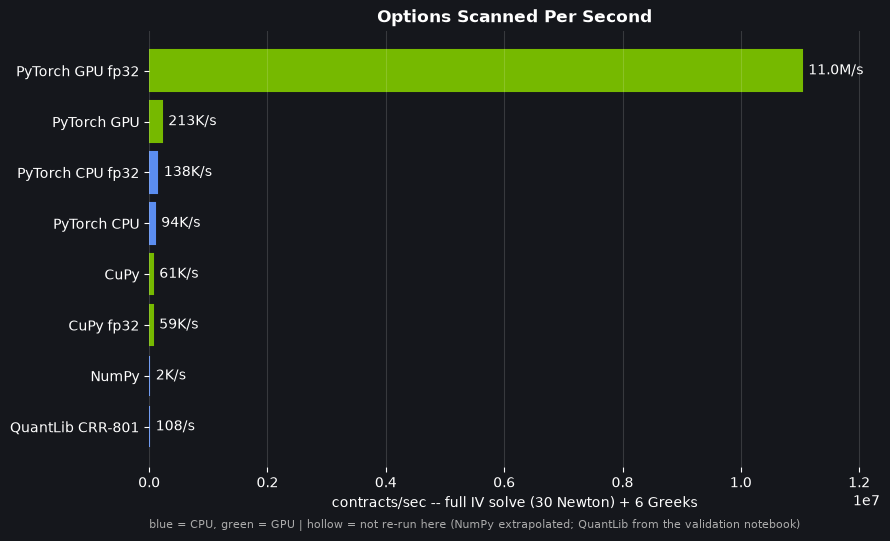

In [26]:
NVIDIA_GREEN = "#76B900"
CPU_BLUE = "#5B8DEF"
DARK_BG = "#15171c"

QL_MS_PER_OPTION = 9.3   # CRR-801, measured on the 5K validation slice

rows = [{"engine": "QuantLib CRR-801", "contracts_per_sec": 1000 / QL_MS_PER_OPTION, "extrapolated": True, "cpu": True}]
rows += [{"engine": b["engine"], "contracts_per_sec": b["contracts_per_sec"],
          "extrapolated": b["extrapolated"],
          "cpu": ("GPU" not in b["engine"]) and ("CuPy" not in b["engine"])} for b in bench]
df = pl.DataFrame(rows).sort("contracts_per_sec")

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(DARK_BG)

for i, r in enumerate(df.iter_rows(named=True)):
    color = CPU_BLUE if r["cpu"] else NVIDIA_GREEN
    solid = not r["extrapolated"]
    ax.barh(i, r["contracts_per_sec"], color=color if solid else "none",
            edgecolor=color, linewidth=1.5)
    v = r["contracts_per_sec"]
    lab = f"{v/1e6:.1f}M/s" if v >= 1e6 else (f"{v/1e3:.0f}K/s" if v >= 1e3 else f"{v:.0f}/s")
    ax.text(v + df["contracts_per_sec"].max() * 0.01, i, lab, va="center", color="white", fontsize=10)

ax.set_yticks(range(df.height)); ax.set_yticklabels(df["engine"].to_list(), color="white")
ax.set_xlim(0, df["contracts_per_sec"].max() * 1.12)
ax.set_xlabel("contracts/sec -- full IV solve (30 Newton) + 6 Greeks", color="white")
ax.set_title("Options Scanned Per Second", color="white", fontweight="bold")
ax.tick_params(colors="white")

for s in ax.spines.values(): s.set_visible(False)

ax.grid(axis="x", alpha=0.15, color="white")

ax.text(0.0, -0.14, "blue = CPU, green = GPU | hollow = not re-run here (NumPy extrapolated; QuantLib from the validation notebook)",
        transform=ax.transAxes, color="#aaaaaa", fontsize=8)

plt.tight_layout(); plt.show()

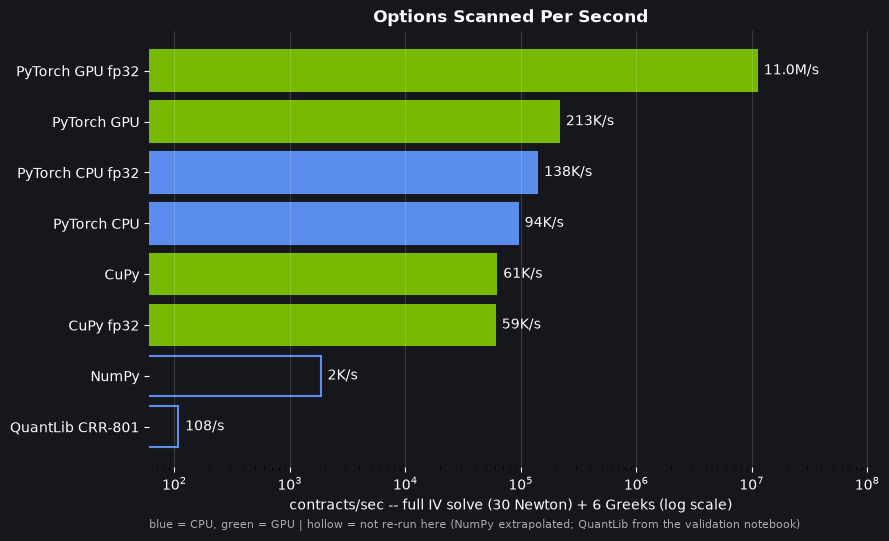

In [27]:
NVIDIA_GREEN = "#76B900"
CPU_BLUE = "#5B8DEF"
DARK_BG = "#15171c"

QL_MS_PER_OPTION = 9.3   # CRR-801, measured on the 5K validation slice

rows = [{"engine": "QuantLib CRR-801", "contracts_per_sec": 1000 / QL_MS_PER_OPTION, "extrapolated": True, "cpu": True}]
rows += [{"engine": b["engine"], "contracts_per_sec": b["contracts_per_sec"],
          "extrapolated": b["extrapolated"],
          "cpu": ("GPU" not in b["engine"]) and ("CuPy" not in b["engine"])} for b in bench]
df = pl.DataFrame(rows).sort("contracts_per_sec")

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(DARK_BG)

for i, r in enumerate(df.iter_rows(named=True)):
    color = CPU_BLUE if r["cpu"] else NVIDIA_GREEN
    solid = not r["extrapolated"]
    ax.barh(i, r["contracts_per_sec"], color=color if solid else "none",
            edgecolor=color, linewidth=1.5)
    v = r["contracts_per_sec"]
    lab = f"{v/1e6:.1f}M/s" if v >= 1e6 else (f"{v/1e3:.0f}K/s" if v >= 1e3 else f"{v:.0f}/s")
    ax.text(v * 1.15, i, lab, va="center", color="white", fontsize=10)

ax.set_yticks(range(df.height)); ax.set_yticklabels(df["engine"].to_list(), color="white")
ax.set_xscale("log"); ax.set_xlim(right=df["contracts_per_sec"].max() * 10)
ax.set_xlabel("contracts/sec -- full IV solve (30 Newton) + 6 Greeks (log scale)", color="white")
ax.set_title("Options Scanned Per Second", color="white", fontweight="bold")
ax.tick_params(colors="white")

for s in ax.spines.values(): s.set_visible(False)

ax.grid(axis="x", alpha=0.15, color="white")

ax.text(0.0, -0.14, "blue = CPU, green = GPU | hollow = not re-run here (NumPy extrapolated; QuantLib from the validation notebook)",
        transform=ax.transAxes, color="#aaaaaa", fontsize=8)

plt.tight_layout(); plt.show()

*Full accuracy shootout (CPU vs GPU) coming: [american_options_shootout.ipynb](american_options_shootout.ipynb).*

# Appendix - Adding DGX Spark Results
RTX PRO 6000 Blackwell workstation vs DGX Spark (GB10, aarch64). Same code, `git clone` apart.

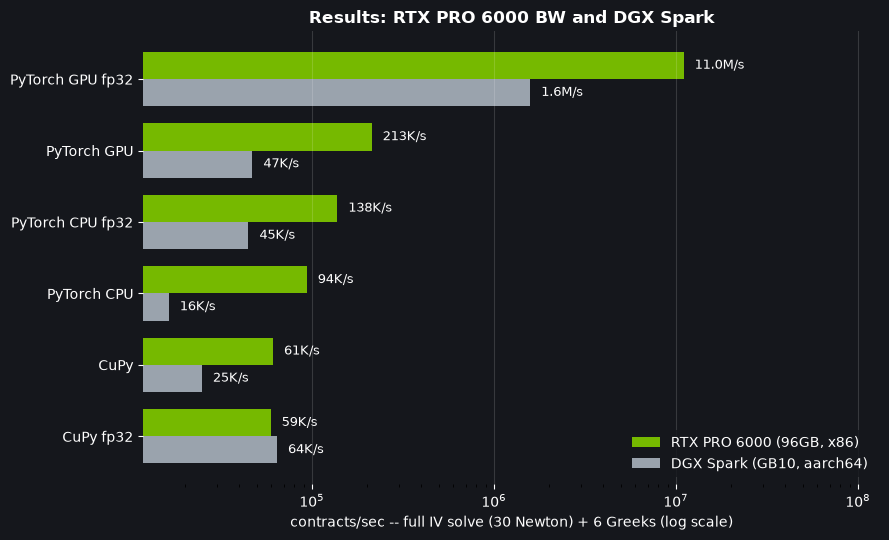

In [29]:
SPARK = {"PyTorch GPU fp32": 1_583_799,
         "CuPy fp32": 64_317,
         "PyTorch GPU": 47_105,
         "PyTorch CPU fp32": 44_794,
         "CuPy": 24_863,
         "PyTorch CPU": 16_363}

b6k_rates = {b["engine"]: b["contracts_per_sec"] for b in bench if b["engine"] in SPARK}
order = sorted(SPARK, key=lambda e: b6k_rates[e])

NVIDIA_GREEN, SPARK_GRAY, DARK_BG = "#76B900", "#9aa3ad", "#15171c"
y = np.arange(len(order)); h = 0.38

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(DARK_BG)
ax.barh(y + h/2, [b6k_rates[e] for e in order], h, color=NVIDIA_GREEN, label="RTX PRO 6000 (96GB, x86)")
ax.barh(y - h/2, [SPARK[e] for e in order], h, color=SPARK_GRAY, label="DGX Spark (GB10, aarch64)")

for yy, e in zip(y, order):
    for off, v in ((h/2, b6k_rates[e]), (-h/2, SPARK[e])):
        lab = f"{v/1e6:.1f}M/s" if v >= 1e6 else f"{v/1e3:.0f}K/s"
        ax.text(v * 1.15, yy + off, lab, va="center", color="white", fontsize=9)

ax.set_yticks(y); ax.set_yticklabels(order, color="white")
ax.set_xscale("log"); ax.set_xlim(right=max(b6k_rates.values()) * 12)
ax.set_xlabel("contracts/sec -- full IV solve (30 Newton) + 6 Greeks (log scale)", color="white")
ax.set_title("Results: RTX PRO 6000 BW and DGX Spark", color="white", fontweight="bold")
ax.tick_params(colors="white")

for s in ax.spines.values(): s.set_visible(False)

ax.grid(axis="x", alpha=0.15, color="white")
ax.legend(facecolor=DARK_BG, edgecolor="none", labelcolor="white", loc="lower right")
plt.tight_layout(); plt.show()